In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import os,sys
import joblib
import shap
import mlflow
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import mlflow.sklearn
from sklearn.model_selection import KFold,cross_val_score,TimeSeriesSplit,GroupKFold
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,VotingRegressor,StackingRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,mean_absolute_percentage_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor




In [2]:
first=pd.read_csv(r'C:\first_data_science_proj\ipl-prediction\data\processed\merged_clean.csv',parse_dates=['date'])
first.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,batting_team_wins
0,335982,1,KKR,RCB,1,1,SC Ganguly,P Kumar,BB McCullum,0,...,M Chinnaswamy Stadium,RCB,KKR,RCB,field,KKR,runs,140.0,223.0,1
1,335982,1,KKR,RCB,1,2,BB McCullum,P Kumar,SC Ganguly,0,...,M Chinnaswamy Stadium,RCB,KKR,RCB,field,KKR,runs,140.0,223.0,1
2,335982,1,KKR,RCB,1,3,BB McCullum,P Kumar,SC Ganguly,0,...,M Chinnaswamy Stadium,RCB,KKR,RCB,field,KKR,runs,140.0,223.0,1
3,335982,1,KKR,RCB,1,4,BB McCullum,P Kumar,SC Ganguly,0,...,M Chinnaswamy Stadium,RCB,KKR,RCB,field,KKR,runs,140.0,223.0,1
4,335982,1,KKR,RCB,1,5,BB McCullum,P Kumar,SC Ganguly,0,...,M Chinnaswamy Stadium,RCB,KKR,RCB,field,KKR,runs,140.0,223.0,1


In [3]:
print(f'shape: {first.shape}')
print(f'columns : {first.columns.tolist()}')
print(f'info: {first.info()}')

shape: (253150, 29)
columns : ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder', 'season', 'date', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'batting_team_wins']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253150 entries, 0 to 253149
Data columns (total 29 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   match_id           253150 non-null  int64         
 1   inning             253150 non-null  int64         
 2   batting_team       253150 non-null  object        
 3   bowling_team       253150 non-null  object        
 4   over               253150 non-null  int64         
 5   ball               253150 non-null  int64         
 6   batter             253150 non

In [4]:
print(f" date range : {first['date'].min()} to {first['date'].max()}")
print(f' unique teams: {first["team1"].unique()}')

 date range : 2008-04-18 00:00:00 to 2024-05-26 00:00:00
 unique teams: ['RCB' 'PBKS' 'DC' 'MI' 'KKR' 'RR' 'SRH' 'CSK' 'KTK' 'PWI' 'GL' 'RPS'
 'LSG' 'GT']


In [5]:
def missing_report(df:pd.DataFrame)->pd.DataFrame:
    m=df.isnull().sum()
    pct=m/len(df)*100
    out=pd.DataFrame({
        'missing':m,
        'missing_pct':pct.round(2),
        'action': pct.apply(lambda x: 'drop' if x> 50 else 'imputer' if x > 0 else 'ok')    }).sort_values('missing_pct',ascending=False)
    display(out[out['missing']>0])
    print(f' columns with zero missing { (m==0).sum()}')
    return out

missing_df=missing_report(first)

,missing,missing_pct,action
fielder,244104,96.43,drop
player_dismissed,240616,95.05,drop
dismissal_kind,240616,95.05,drop
extras_type,239465,94.59,drop


 columns with zero missing 25


In [6]:
first['season_yr']=first['date'].dt.year.astype(int)

First innings rows : 130,528
Unique matches     : 1,055
Seasons            : [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


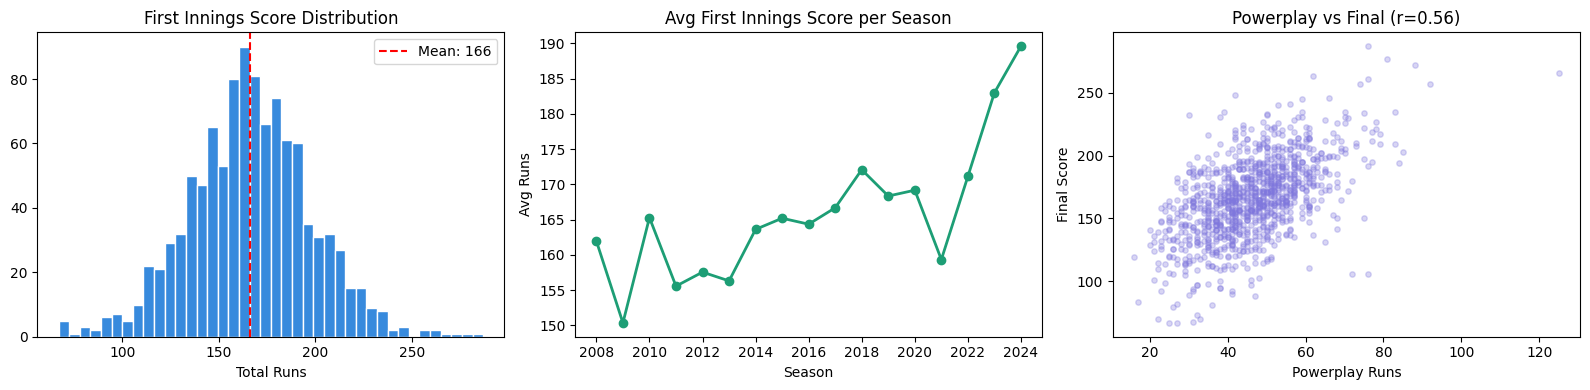

In [7]:
first_inn=(
    first[first['inning']==1]
    .copy()
    .sort_values(['match_id','over','ball'])
    .reset_index(drop=True)
)

print(f'First innings rows : {first_inn.shape[0]:,}')
print(f'Unique matches     : {first_inn.match_id.nunique():,}')
print(f'Seasons            : {sorted(first_inn.season_yr.unique())}')

# ── EDA plots
total_eda  = first_inn.groupby('match_id')['total_runs'].sum()
season_avg = (
    first_inn.groupby(['match_id', 'season_yr'])['total_runs']
    .sum().reset_index()
    .groupby('season_yr')['total_runs'].mean()
)
pp_data = first_inn[first_inn['over'] <= 6].groupby('match_id')['total_runs'].sum()
pp_df   = pd.DataFrame({'pp_runs': pp_data, 'final': total_eda}).dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(total_eda, bins=40, color='#378ADD', edgecolor='white')
axes[0].axvline(total_eda.mean(), color='red', linestyle='--',
                label=f'Mean: {total_eda.mean():.0f}')
axes[0].set_title('First Innings Score Distribution')
axes[0].set_xlabel('Total Runs'); axes[0].legend()

axes[1].plot(season_avg.index, season_avg.values, 'o-', color='#1D9E75', linewidth=2)
axes[1].set_title('Avg First Innings Score per Season')
axes[1].set_xlabel('Season'); axes[1].set_ylabel('Avg Runs')

axes[2].scatter(pp_df['pp_runs'], pp_df['final'], alpha=0.3, color='#7F77DD', s=15)
corr = pp_df.corr().loc['pp_runs', 'final']
axes[2].set_title(f'Powerplay vs Final (r={corr:.2f})')
axes[2].set_xlabel('Powerplay Runs'); axes[2].set_ylabel('Final Score')

plt.tight_layout()
plt.show()



In [8]:
# ╔══════════════════════════════════════════════════╗
# ║  CELL 5 — POWERPLAY AGGREGATION (overs 1–6)     ║
# ╚══════════════════════════════════════════════════╝
powerplay = first_inn[first_inn['over'] <= 6].copy()

pp_agg = powerplay.groupby('match_id').agg(
    pp_runs        = ('total_runs',   'sum'),
    pp_wickets     = ('is_wicket',    'sum'),
    pp_fours       = ('batsman_runs', lambda x: (x == 4).sum()),
    pp_sixes       = ('batsman_runs', lambda x: (x == 6).sum()),
    pp_dot_balls   = ('batsman_runs', lambda x: (x == 0).sum()),
    pp_legal_balls = ('extras_type',  lambda x: x.isna().sum()),
    batting_team   = ('batting_team', 'first'),
    bowling_team   = ('bowling_team', 'first'),
    venue          = ('venue',        'first'),
    season_yr      = ('season_yr',    'first'),
    date           = ('date',         'first'),
).reset_index()

pp_agg['pp_crr']            = (pp_agg['pp_runs'] / 6).round(3)
pp_agg['pp_boundaries']     = pp_agg['pp_fours'] + pp_agg['pp_sixes']
pp_agg['pp_dot_pct']        = (pp_agg['pp_dot_balls']  / pp_agg['pp_legal_balls'].clip(lower=1)).round(3)
pp_agg['pp_boundary_pct']   = (pp_agg['pp_boundaries'] / pp_agg['pp_legal_balls'].clip(lower=1)).round(3)
pp_agg['pp_runs_per_wicket']= (pp_agg['pp_runs'] / (pp_agg['pp_wickets'] + 1)).round(3)

print(f'Powerplay feature matrix: {pp_agg.shape}')
pp_agg[['pp_runs','pp_wickets','pp_crr','pp_dot_pct','pp_boundary_pct','pp_runs_per_wicket']].describe().round(2)

Powerplay feature matrix: (1055, 17)


,pp_runs,pp_wickets,pp_crr,pp_dot_pct,pp_boundary_pct,pp_runs_per_wicket
count,1055.00,1055.00,1055.00,1055.00,1055.00,1055.00
mean,46.20,1.38,7.70,0.54,0.20,25.63
std,12.05,1.08,2.01,0.12,0.07,17.11
min,16.00,0.00,2.67,0.17,0.03,3.40
25%,38.00,1.00,6.33,0.47,0.14,13.33
50%,46.00,1.00,7.67,0.54,0.19,20.50
75%,53.50,2.00,8.92,0.63,0.24,30.50
max,125.00,5.00,20.83,0.91,0.69,125.00


In [9]:
# ╔══════════════════════════════════════════════════╗
# ║  CELL 6 — MIDDLE OVERS FEATURES (overs 7–15)   ║
# ╚══════════════════════════════════════════════════╝
# WHY: Middle overs momentum (run rate + wickets 7–15) is highly predictive
# of final score and was missing from v2.
middle = first_inn[(first_inn['over'] >= 7) & (first_inn['over'] <= 15)].copy()

mid_agg = middle.groupby('match_id').agg(
    mid_runs    = ('total_runs', 'sum'),
    mid_wickets = ('is_wicket',  'sum'),
    mid_balls   = ('extras_type', lambda x: x.isna().sum()),
).reset_index()

mid_agg['mid_crr']        = (mid_agg['mid_runs'] / 9).round(3)   # 9 overs
mid_agg['mid_run_per_wkt']= (mid_agg['mid_runs'] / (mid_agg['mid_wickets'] + 1)).round(3)

# Merge with powerplay
pp_agg = pp_agg.merge(mid_agg[['match_id','mid_runs','mid_wickets','mid_crr','mid_run_per_wkt']],
                      on='match_id', how='left')

# Fill matches where middle overs data is missing (e.g. rain interruptions)
for col in ['mid_runs','mid_wickets','mid_crr','mid_run_per_wkt']:
    pp_agg[col] = pp_agg[col].fillna(pp_agg[col].median())

print(f'After middle-overs merge: {pp_agg.shape}')
pp_agg[['mid_runs','mid_wickets','mid_crr','mid_run_per_wkt']].describe().round(2)

After middle-overs merge: (1055, 21)


,mid_runs,mid_wickets,mid_crr,mid_run_per_wkt
count,1055.00,1055.00,1055.00,1055.00
mean,69.83,2.23,7.76,27.31
std,17.00,1.26,1.89,18.92
min,30.00,0.00,3.33,4.71
25%,58.00,1.00,6.44,15.50
50%,69.00,2.00,7.67,22.33
75%,80.00,3.00,8.89,33.00
max,143.00,7.00,15.89,143.00


In [10]:
train_season=[2019,2020,2021,2022,2023]
test_season=[2024]


match_totals = (
    first_inn
    .groupby(['match_id','venue','season_yr','date','batting_team','bowling_team'])
    ['total_runs'].sum().reset_index()
    .rename(columns={'total_runs': 'match_total'})
)

# ── Venue avg: TRAIN seasons only (BUG FIX)
train_match_totals = match_totals[match_totals['season_yr'].isin(train_season)]
venue_avg_map = train_match_totals.groupby('venue')['match_total'].mean().round(2)
global_avg    = train_match_totals['match_total'].mean()
pp_agg['venue_avg_score'] = pp_agg['venue'].map(venue_avg_map).fillna(global_avg)

# Pre-sort lookup tables (big speed improvement vs repeated filtering)
mt_sorted  = match_totals.sort_values('date')
pp_sorted  = (
    powerplay.groupby(['match_id','bowling_team','season_yr','date'])['total_runs']
    .sum().reset_index()
    .assign(pp_economy_val=lambda d: d['total_runs'] / 6)
    .sort_values('date')
)

# ── 1. Batting team season avg (date-gated)
def batting_team_season_avg(team, season_yr, before_date):
    past = mt_sorted.loc[
        (mt_sorted['batting_team'] == team) &
        (mt_sorted['season_yr']    == season_yr) &
        (mt_sorted['date']         <  before_date)
    ]
    return round(past['match_total'].mean(), 2) if len(past) >= 2 else global_avg

# ── 2. Bowling team powerplay economy (date-gated)
def bowling_team_pp_econ(team, season_yr, before_date):
    past = pp_sorted.loc[
        (pp_sorted['bowling_team'] == team) &
        (pp_sorted['season_yr']    == season_yr) &
        (pp_sorted['date']         <  before_date)
    ]
    return round(past['pp_economy_val'].mean(), 3) if len(past) >= 2 else 8.5

# ── 3. Rolling 3-match team form (date-gated) — NEW in v3
def batting_team_rolling3(team, before_date):
    past = mt_sorted.loc[
        (mt_sorted['batting_team'] == team) &
        (mt_sorted['date']         <  before_date)
    ].tail(3)
    return round(past['match_total'].mean(), 2) if len(past) >= 1 else global_avg

# ── 4. Head-to-head avg (date-gated) — NEW in v3
def h2h_avg(bat_team, bowl_team, before_date):
    past = mt_sorted.loc[
        (mt_sorted['batting_team'] == bat_team) &
        (mt_sorted['bowling_team'] == bowl_team) &
        (mt_sorted['date']         <  before_date)
    ]
    return round(past['match_total'].mean(), 2) if len(past) >= 2 else global_avg

print('Computing batting_team_season_avg …')
pp_agg['batting_team_season_avg'] = pp_agg.apply(
    lambda r: batting_team_season_avg(r['batting_team'], r['season_yr'], r['date']), axis=1)

print('Computing bowling_team_pp_economy …')
pp_agg['bowling_team_pp_economy'] = pp_agg.apply(
    lambda r: bowling_team_pp_econ(r['bowling_team'], r['season_yr'], r['date']), axis=1)

print('Computing batting_team_rolling3 …')
pp_agg['batting_team_rolling3'] = pp_agg.apply(
    lambda r: batting_team_rolling3(r['batting_team'], r['date']), axis=1)

print('Computing h2h_avg …')
pp_agg['h2h_avg'] = pp_agg.apply(
    lambda r: h2h_avg(r['batting_team'], r['bowling_team'], r['date']), axis=1)

print('✅ All contextual features done')
pp_agg[['venue_avg_score','batting_team_season_avg',
        'bowling_team_pp_economy','batting_team_rolling3','h2h_avg']].describe().round(2)

Computing batting_team_season_avg …
Computing bowling_team_pp_economy …
Computing batting_team_rolling3 …
Computing h2h_avg …
✅ All contextual features done


,venue_avg_score,batting_team_season_avg,bowling_team_pp_economy,batting_team_rolling3,h2h_avg
count,1055.00,1055.00,1055.00,1055.00,1055.00
mean,172.41,168.71,7.95,165.95,163.63
std,9.90,16.31,0.99,20.45,11.96
min,144.12,97.00,4.58,100.00,102.00
25%,170.74,160.25,7.26,152.42,156.21
50%,170.74,170.74,8.21,166.33,166.00
75%,175.08,175.50,8.50,179.33,170.74
max,200.00,240.00,11.28,251.33,220.00


In [11]:
y_df=match_totals[['match_id','match_total']].rename(columns={'match_total':'y'})
model_df=pp_agg.merge(y_df,on='match_id',how='inner')


model_df['is_impact_era']=(model_df['season_yr']>=2023).astype(int)
model_df['is_t20_boom_era']=(model_df['season_yr']>=2021).astype(int)
model_df['is_pre2022']=(model_df['season_yr']< 2022).astype(int)

num_fill=model_df.select_dtypes(include=np.number).columns
model_df[num_fill]=model_df[num_fill].fillna(model_df[num_fill].median())

print(f'model_df shape : {model_df.shape}')
print(f'null check : {model_df.isnull().sum().sum()}')
print(f' season : {sorted(model_df.season_yr.unique())}')
print(f'\n target stats')
print(model_df['y'].describe().round(1))

# want to save the pd.to_csv for model_df

# FEATURES_CSV = f'{ARTIFACT_DIR}/model3_features.csv'
# model_df.to_csv(FEATURES_CSV, index=False)
# print(f'\n✅ Features saved → {FEATURES_CSV}')


model_df shape : (1055, 30)
null check : 0
 season : [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

 target stats
count    1055.0
mean      166.1
std        31.7
min        67.0
25%       146.0
50%       165.0
75%       186.5
max       287.0
Name: y, dtype: float64


In [12]:
feature_cols=[
    'pp_runs', 'pp_wickets', 'pp_crr',
    'pp_fours', 'pp_sixes', 'pp_boundaries',
    'pp_dot_pct', 'pp_boundary_pct', 'pp_runs_per_wicket',
    # Middle overs (NEW)
    'mid_runs', 'mid_wickets', 'mid_crr', 'mid_run_per_wkt',
    # Date-gated contextual
    'venue_avg_score', 'batting_team_season_avg',
    'bowling_team_pp_economy',
    'batting_team_rolling3',  # NEW
    'h2h_avg',                # NEW
    # Categorical
    'batting_team', 'bowling_team', 'venue',
    # Era flags
    'season_yr', 'is_impact_era', 'is_t20_boom_era', 'is_pre2022',

]

train_df=model_df[model_df['season_yr'].isin(train_season)].sort_values('date')
test_df=model_df[model_df['season_yr'].isin(test_season)].sort_values('date')


x_train=train_df[feature_cols].reset_index(drop=True)
y_train=train_df['y'].reset_index(drop=True)
x_test=test_df[feature_cols].reset_index(drop=True)
y_test=test_df['y'].reset_index(drop=True)

print(f'training seasons : {train_season}')
print(f'test_season: {test_season}')
print(f' x_train shape: {x_train.shape} -> range : {y_train.min():.0f}–{y_train.max():.0f}')
print(f'x_ test shape : {x_test.shape} -> y range : {y_test.min():.0f}–{y_test.max():.0f}')
print(f' train row : {len(x_train)} matches ')

baseline_mae=mean_absolute_error(y_train,np.full(len(y_train),y_train.mean()))
baseline_rmse=mean_squared_error(y_train,np.full(len(y_train),y_train.mean()))**0.5


print(f'\nbaseline (mean pred ) mae : {baseline_mae:.1f}')
print(f'basline (mean pred) rmse: {baseline_rmse:.1f}')
print(f' target mae : < {baseline_mae*0.5:.1f}')

training seasons : [2019, 2020, 2021, 2022, 2023]
test_season: [2024]
 x_train shape: (317, 25) -> range : 68–257
x_ test shape : (71, 25) -> y range : 89–287
 train row : 317 matches 

baseline (mean pred ) mae : 24.4
basline (mean pred) rmse: 30.9
 target mae : < 12.2


In [13]:
cat_cols=['batting_team', 'bowling_team', 'venue']

num_cols=[
    'pp_crr', 'pp_dot_pct', 'pp_boundary_pct',
    'mid_crr', 'mid_run_per_wkt',
    'venue_avg_score', 'batting_team_season_avg',
    'bowling_team_pp_economy', 'batting_team_rolling3', 'h2h_avg',
]

pass_cols=[
    'pp_runs', 'pp_wickets', 'pp_fours', 'pp_sixes',
    'pp_boundaries', 'pp_runs_per_wicket',
    'mid_runs', 'mid_wickets',
    'season_yr', 'is_impact_era', 'is_t20_boom_era', 'is_pre2022',
]

assert set(cat_cols +num_cols + pass_cols)==set(feature_cols),\
    f' mistmatch missing : {set(feature_cols)-set(cat_cols + num_cols + pass_cols)}'


preprocessor=ColumnTransformer(
    transformers=[
        ('cat',OneHotEncoder(handle_unknown='ignore',sparse_output=False),cat_cols),
        ('num',Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaling',StandardScaler())
        ]),num_cols),
        ('pass','passthrough',pass_cols),

    ],remainder='drop'
)

In [14]:
mmoldels={
    'lg':LinearRegression(),
    'rf':RandomForestRegressor(n_estimators=400,max_depth=3,min_samples_leaf=10,max_features='sqrt',random_state=42,n_jobs=-1),
    'xgb':XGBRegressor(n_estimators=400,max_depth=3,learning_rate=0.05,min_child_weight=15,reg_alpha=1.0,reg_lambda=5.0,rantom_state=42),
    'lgbm': LGBMRegressor(n_estimators=300,max_depth=8,min_samples_leaves=10,subsample=8,min_child_samples=15,reg_alpha=1.0,reg_lambda=5.0,random_state=42)
}

In [15]:
tscv=TimeSeriesSplit(n_splits=5)

def cv_mae_plain(pipeline,x,y):
    scores=[]
    for tr, val in tscv.split(x):
        pipeline.fit(x.iloc[tr],y.iloc[tr])
        scores.append(mean_absolute_error(y.iloc[val],pipeline.predict(x.iloc[val])))
    return np.mean(scores)

def cv_mae_early(model_cls,model_params,preproc,x,y,es_rounds=20):
    scores=[]
    for tr,val in tscv.split(x):
        x_tr,y_tr=x.iloc[tr],y.iloc[tr]
        x_val,y_val=x.iloc[val],y.iloc[val]

        preproc_fit=preproc.__class(**preproc.get_params())

        pipe=Pipeline([('preprocessor',preproc),
                       ('model',model_cls(**model_params))])
        
        pipe.fit(
            x_tr,y_tr,m__eval_set =[(pipe.named_steps['preprocessor'].fit_transform(x_val),y_val)]\
            if False else None,

        )

        scores.append(mean_absolute_error(y_val,pipe.predict(x_val)))
    return np.mean(scores)

def xgb_objective(trail):
    params=dict(
        n_estimators=trail.suggest_int('n_estimators',100,600),
        max_depth=trail.suggest_int('max_depth',2,6),
        learning_rate=trail.suggest_float('lr',0.005,0.1,log=True),
        subsample=trail.suggest_float('subsample',0.5,0.9),
        colsample_bytree=trail.suggest_float('colsample_bytree',0.4,0.9),
        min_child_weight=trail.suggest_int('min_child_weight',10,50),
        reg_alpha=trail.suggest_float('reg_alpha',1.0,10.0),
        reg_lambda=trail.suggest_float('reg_lambda',1.0,15.0),
        gamma=trail.suggest_float('gamma',0.0,5.0),
        random_state=42,n_jobs=-1,verbosity=0,
    )

    pipe=Pipeline([('preprocessor',preprocessor),
                   ('model',XGBRegressor(**params))])
    return cv_mae_plain(pipe,x_train,y_train)

def lgbm_objective(trial):
    params=dict(
        n_estimators      = trial.suggest_int('n_estimators', 100, 600),
        max_depth         = trial.suggest_int('max_depth', 2, 6),
        learning_rate     = trial.suggest_float('lr', 0.005, 0.1, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 10, 40),   # small — anti overfit
        subsample         = trial.suggest_float('subsample', 0.5, 0.9),
        min_child_samples = trial.suggest_int('min_child_samples', 20, 80),  # strong
        reg_alpha         = trial.suggest_float('reg_alpha', 1.0, 10.0),
        reg_lambda        = trial.suggest_float('reg_lambda', 1.0, 15.0),
        min_gain_to_split = trial.suggest_float('min_gain_to_split', 0.0, 2.0),  # new
        random_state      = 42, n_jobs=-1, verbose=-1,
    )

    pipe=Pipeline([('preprocessor',preprocessor),
                   ('model',LGBMRegressor(**params))])
    return cv_mae_plain(pipe,x_train,y_train)



print('optuna tune xgb')

xgb_study=optuna.create_study(direction='minimize',pruner=optuna.pruners.MedianPruner(n_warmup_steps=10))
xgb_study.optimize(xgb_objective,n_trials=50,show_progress_bar=True)
best_xgb_p=xgb_study.best_params.copy()
best_xgb_p['learning_rate']=best_xgb_p.pop('lr')
best_xgb_p.update({'random_state':42,'n_jobs':-1,'verbosity':0})
print(f' best xgb cv mae : {xgb_study.best_value:.2f} runs')



print('optuna tune')
lgbm_study=optuna.create_study(direction='minimize',pruner=optuna.pruners.MedianPruner(n_warmup_steps=10))
lgbm_study.optimize(lgbm_objective,n_trials=50,show_progress_bar=True)
best_lgbm_p=lgbm_study.best_params.copy()
best_lgbm_p['learning_rate']=best_lgbm_p.pop('lr')
best_lgbm_p.update({'random_state':42,'n_jobs':-1,'verbose':-1})
print(f'best lgbm cv mae : {lgbm_study.best_value:.2f}runs')

print(f'tuning results')
print(f'xgb params: {best_xgb_p}')
print(f'lgbm params: {best_lgbm_p}')




optuna tune xgb


  0%|          | 0/50 [00:00<?, ?it/s]

 best xgb cv mae : 12.70 runs
optuna tune


  0%|          | 0/50 [00:00<?, ?it/s]

best lgbm cv mae : 13.89runs
tuning results
xgb params: {'n_estimators': 224, 'max_depth': 2, 'subsample': 0.7655056916708505, 'colsample_bytree': 0.5949422402399828, 'min_child_weight': 12, 'reg_alpha': 3.012665093347548, 'reg_lambda': 2.4520537677195007, 'gamma': 3.674066905086955, 'learning_rate': 0.03190891525134361, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}
lgbm params: {'n_estimators': 244, 'max_depth': 2, 'num_leaves': 13, 'subsample': 0.7353992029624776, 'min_child_samples': 24, 'reg_alpha': 7.169257544512557, 'reg_lambda': 6.634252282101572, 'min_gain_to_split': 0.28910198367422457, 'learning_rate': 0.03997466354820757, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


In [16]:
xgb_model_pipe=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',XGBRegressor(**best_xgb_p))
])


lgbm_model_pipe=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',LGBMRegressor(**best_lgbm_p))
])
lgbm_model_pipe.fit(x_train,y_train)
xgb_model_pipe.fit(x_train,y_train)

lgbm_train_pred=lgbm_model_pipe.predict(x_train)
xgb_train_pred=xgb_model_pipe.predict(x_train)
lgbm_pred=lgbm_model_pipe.predict(x_test)
xgb_pred=xgb_model_pipe.predict(x_test)

print(f'\n lgbm train mae: {mean_absolute_error(y_train,lgbm_train_pred):.2f}')
print(f'xgb train mae: {mean_absolute_error(y_train,xgb_train_pred):.2f}')




 lgbm train mae: 8.88
xgb train mae: 9.07


In [17]:
#ensemble
tuned_xgb=XGBRegressor(**best_xgb_p)
tuned_lgbm=LGBMRegressor(**best_lgbm_p)

tuned_rf=RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    max_features=0.6,
    random_state=42,
    n_jobs=-1,
)

from sklearn.model_selection import KFold
stacking_cv=KFold(n_splits=5,shuffle=False)

stacker=StackingRegressor(
    estimators=[
        ('xgb',tuned_xgb),
        ('lgbm',tuned_lgbm),
        ('rf',tuned_rf),

    ],
    final_estimator=Ridge(alpha=10.0),
    cv=stacking_cv,
    passthrough=False,
    n_jobs=-1,
)

final_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('stacker',stacker),
])

print('fitting to the ensemble pipeline')
final_pipeline.fit(x_train,y_train)

train_preds_quick=final_pipeline.predict(x_train)
print(f' train mae:  {mean_absolute_error(y_train,train_preds_quick):.2f}')

fitting to the ensemble pipeline
 train mae:  8.89


In [18]:
from sklearn.model_selection import cross_validate

In [20]:
#cross validation

cv_results=cross_validate(
    final_pipeline,x_train,y_train,cv=tscv,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    n_jobs=-1,

)

cv_train_maes=-cv_results['train_score']
cv_val_maes=-cv_results['test_score']

mean_cv_train=cv_train_maes.mean()
mean_cv_val=cv_val_maes.mean()
std_cv_val=cv_val_maes.std()


print(f'\n fold-wise val mae: {np.round(cv_val_maes,1)}')
print(f'cv train mae: {mean_cv_train:.2f} runs')
print (f' cv val mae : {mean_cv_val:.2f} runs +_ {std_cv_val:.2f}')
print(f' cv overfit gap : {mean_cv_val - mean_cv_train:.2f}')


#stability checkng
gap=mean_cv_val - mean_cv_train
if cv_train_maes.mean() <3 and mean_cv_val >15:
    print(f' severe overfitting')
elif gap > 8:
    print(f'mild overfitting')
elif mean_cv_val > baseline_mae * 0.75:
    print(f'underfitting')
elif gap <6 and std_cv_val < 5:
    print(f'good fit ')
else: 
    print(f' acceptable fit')


print(f'\n retraining the full x_train and final evaluation')
final_pipeline.fit(x_train,y_train)

y_train_pred=final_pipeline.predict(x_train)
train_mae=mean_absolute_error(y_train,y_train_pred)
train_rmse=mean_squared_error(y_train,y_train_pred)**0.5

print(f' final train mae: {train_mae:.1f}')
print(f' final train rmse: {train_rmse:.1f}')

mean_cv_mae=mean_cv_val
std_cv_mae=std_cv_val


 fold-wise val mae: [23.8 12.  11.7 11.7 10.7]
cv train mae: 11.78 runs
 cv val mae : 13.99 runs +_ 4.93
 cv overfit gap : 2.21
good fit 

 retraining the full x_train and final evaluation
 final train mae: 8.9
 final train rmse: 11.2


In [22]:
# test evaluation

y_pred=final_pipeline.predict(x_test)

test_mae=mean_absolute_error(y_test,y_pred)
test_rmse=mean_squared_error(y_test,y_pred)**0.5

test_r2=r2_score(y_test,y_pred)
test_mape=mean_absolute_percentage_error(y_test,y_pred)*100.0

within_10=(np.abs(y_test-y_pred)<=10).mean()*100.0
within_15=(np.abs(y_test-y_pred)<=15).mean()*100.0
within_20=(np.abs(y_test-y_pred)<=20).mean()*100.0
improvement=(1-test_mae/baseline_mae)*100.0

print(f' test evaluation results and predictins')

print(f'baseline mae : {baseline_mae:.1f}')
print(f'model test mae: {test_mae:.2f}')
print(f'model test rmse: {test_rmse:.2f}')
print(f'model test r2 : {test_r2:.4f}')
print(f'mape: {test_mape:.2f}%')
print(f' improvement vs baseline: {improvement:.2f}%')

print()
print(f'within +-10 runs: {within_10:.2f}%')
print(f'within +-15 runs: {within_15:.1f}%')
print(f'within +-20 runs: {within_20:.1f}%')

print(f' \n bias-variance summary')
print(f' train_mae: {train_mae:.1f}')
print(f' cv mae: {mean_cv_mae:.1f} +- {std_cv_mae:.1f}')
print(f' test mae : {test_mae:.1f}')
overfit_flag=mean_cv_mae - train_mae
print(f"gap (cv -train): {overfit_flag:.1f} {'good fit' if overfit_flag<6 else 'overfitting'}")

compare_df=pd.DataFrame({
    'actual(2024)':y_test.values[:10],
    'predicted(2024)':np.round(y_pred[:10]).astype(int),
    'abs error':np.abs(y_test.values[:10]-y_pred[:10]).round(1)

})
print(f'\n sample prediction vs actual')
print(compare_df.to_string(index=False))

 test evaluation results and predictins
baseline mae : 24.4
model test mae: 14.09
model test rmse: 19.79
model test r2 : 0.7325
mape: 7.26%
 improvement vs baseline: 42.20%

within +-10 runs: 53.52%
within +-15 runs: 67.6%
within +-20 runs: 74.6%
 
 bias-variance summary
 train_mae: 8.9
 cv mae: 14.0 +- 4.9
 test mae : 14.1
gap (cv -train): 5.1 good fit

 sample prediction vs actual
 actual(2024)  predicted(2024)  abs error
          173              150       23.1
          174              172        1.7
          208              177       30.9
          193              198        5.0
          168              177        8.5
          176              187       11.1
          206              207        1.2
          277              228       49.3
          185              160       25.3
          182              192       10.3


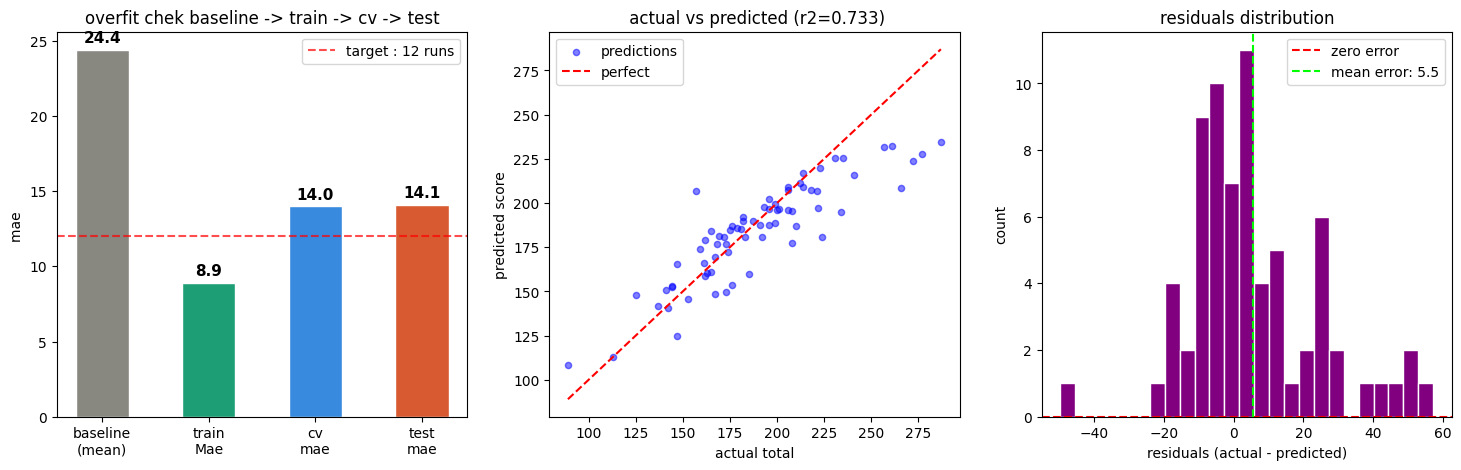

In [26]:
fig,axes=plt.subplots(1,3,figsize=(18,5))
labels=['baseline\n(mean)','train\nMae','cv\nmae','test\nmae']
values=[baseline_mae,train_mae,mean_cv_mae,test_mae]

colors=['#888780', '#1D9E75', '#378ADD', '#D85A30']
bars=axes[0].bar(labels,values,color=colors,width=0.5,edgecolor='white')
for bar,val in zip(bars,values):
    axes[0].text(bar.get_x() + bar.get_width()/2,bar.get_height()  + 0.3,
               f'{val:.1f}',ha='center',va='bottom',fontsize=11,fontweight='bold')
axes[0].axhline(12,color='red',linestyle='--',alpha=0.7,label='target : 12 runs')
axes[0].set_ylabel('mae ')
axes[0].set_title('overfit chek baseline -> train -> cv -> test')
axes[0].legend()

axes[1].scatter(y_test,y_pred,alpha=0.5,color='blue',s=20,label='predictions')
mn,mx=min(y_test.min(),y_pred.min()),max(y_test.max(),y_pred.max())
axes[1].plot([mn,mx],[mn,mx],'r--',linewidth=1.5,label='perfect')
axes[1].set_xlabel('actual total')
axes[1].set_ylabel('predicted score')
axes[1].set_title(f' actual vs predicted (r2={test_r2:.3f})')
axes[1].legend()

residuals=y_test.values -y_pred
axes[2].hist(residuals,bins=25,color='purple',edgecolor='white')
axes[2].axhline(0,color='red',linestyle='--',linewidth=1.5,label='zero error')
axes[2].axvline(residuals.mean(),color='lime',linestyle='--',label=f'mean error: {residuals.mean():.1f}')
axes[2].set_xlabel('residuals (actual - predicted)')
axes[2].set_ylabel('count')
axes[2].set_title('residuals distribution')
axes[2].legend()

plt.show()
    

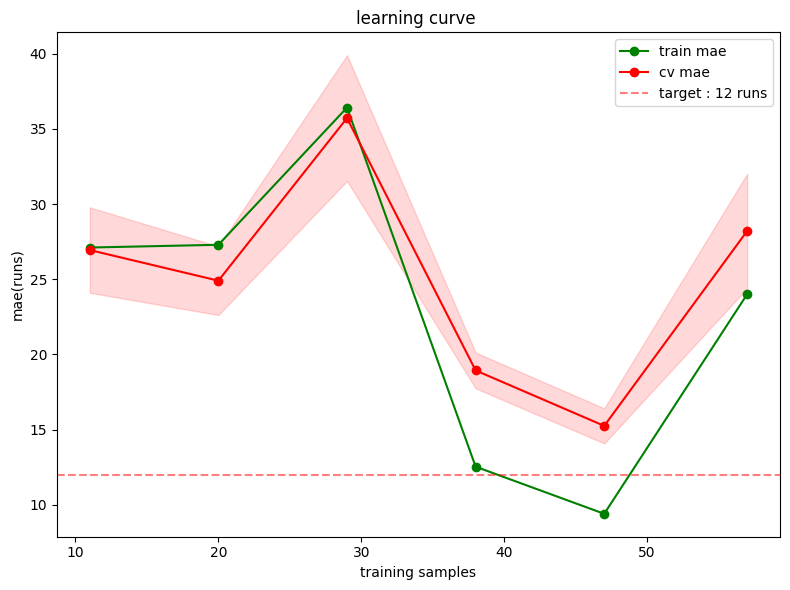

In [30]:
# learning curve
from sklearn.model_selection import learning_curve

train_sizes,train_scores,val_scores=learning_curve(
    final_pipeline,x_train,y_train,cv=tscv,
    train_sizes=np.linspace(0.2,1.0,6),
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)

train_mae_lc=-train_scores.mean(axis=1)
val_mae_lc=-val_scores.mean(axis=1)
val_std_lc=val_scores.std(axis=1)

fig,ax=plt.subplots(figsize=(8,6))
ax.plot(train_sizes,train_mae_lc,'o-',color='green',label='train mae')
ax.plot(train_sizes,val_mae_lc,'o-',color='red',label='cv mae')
ax.fill_between(train_sizes,val_mae_lc-val_std_lc,val_mae_lc+val_std_lc,alpha=0.15,color='red')
ax.axhline(12,color='red',linestyle='--',alpha=0.5,label='target : 12 runs')
ax.set_xlabel('training samples')
ax.set_ylabel('mae(runs)')
ax.set_title('learning curve ')
ax.legend()
plt.tight_layout()
plt.show()

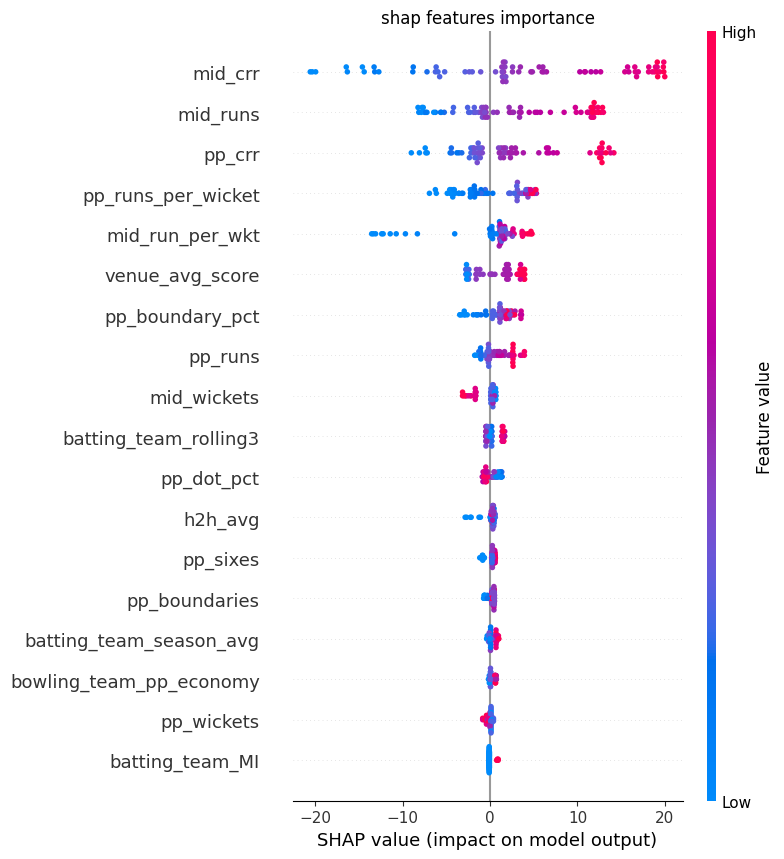

In [32]:
# shap explainability

xgb_in_stacker=final_pipeline.named_steps['stacker'].estimators_[0]
x_train_transformed=final_pipeline.named_steps['preprocessor'].transform(x_train)
x_test_transformed=final_pipeline.named_steps['preprocessor'].transform(x_test)

try:
    ohe_name=(
        final_pipeline.named_steps['preprocessor']
        .named_transformers_['cat']
        .get_feature_names_out(cat_cols).tolist()
    )

    feat_names=ohe_name + num_cols + pass_cols
except Exception :
    feat_names=[f'f{i}' for i in range(x_train_transformed.shape[1])]

explainer=shap.TreeExplainer(xgb_in_stacker)

shap_values=explainer.shap_values(x_test_transformed)

plt.figure(figsize=(10,7))
shap.summary_plot(shap_values,x_test_transformed,feature_names=feat_names,max_display=18,show=False)
plt.title('shap features importance')
plt.tight_layout()

plt.show()